In [2]:
import pandas as pd
import glob

# combine all chunks
files = sorted(glob.glob('/kaggle/input/datasets/adyanmukadam/mimic-iv-mortality-features/chunk_*.csv'))
df = pd.concat([pd.read_csv(f) for f in files])
print(df.shape)
print(df['hospital_expire_flag'].value_counts())
print(df['hospital_expire_flag'].value_counts(normalize=True))

(94458, 138)
hospital_expire_flag
0    83108
1    11350
Name: count, dtype: int64
hospital_expire_flag
0    0.879841
1    0.120159
Name: proportion, dtype: float64


In [3]:
# check missing values
missing = df.isnull().mean()
print(f'Columns with >50% missing: {(missing > 0.5).sum()}')
print(f'Columns with >70% missing: {(missing > 0.7).sum()}')
print(missing[missing > 0.5].sort_values(ascending=False))

Columns with >50% missing: 38
Columns with >70% missing: 32
thrombin_min              0.998306
thrombin_max              0.998306
ggt_min                   0.992632
ggt_max                   0.992632
d_dimer_max               0.988905
d_dimer_min               0.988905
globulin_min              0.988619
globulin_max              0.988619
total_protein_max         0.978975
total_protein_min         0.978975
bilirubin_indirect_min    0.960522
bilirubin_indirect_max    0.960522
bilirubin_direct_min      0.957971
bilirubin_direct_max      0.957971
amylase_max               0.942535
amylase_min               0.942535
nrbc_max                  0.940302
nrbc_min                  0.940302
atyps_min                 0.897267
atyps_max                 0.897267
metas_min                 0.890766
metas_max                 0.890766
bands_max                 0.878909
bands_min                 0.878909
fibrinogen_min            0.741716
fibrinogen_max            0.741716
imm_granulocytes_max      0.73

In [4]:
# drop high missing columns
threshold = 0.7
cols_to_drop = missing[missing > threshold].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f'Remaining columns: {df.shape[1]}')

Remaining columns: 106


In [5]:
id_cols = ['subject_id', 'stay_id', 'hadm_id']
id_cols = [c for c in id_cols if c in df.columns]
df = df.drop(columns=id_cols)
print(df.shape)

(94458, 103)


In [6]:
X = df.drop(columns=['hospital_expire_flag'])
y = df['hospital_expire_flag']

# categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f'{col}: {X[col].nunique()} unique values')

['first_careunit', 'admission_type', 'race', 'sepsis3']
first_careunit: 17 unique values
admission_type: 9 unique values
race: 33 unique values
sepsis3: 1 unique values


In [7]:
X = X.drop(columns=['sepsis3'])
cat_cols.remove('sepsis3')

In [8]:
from sklearn.preprocessing import LabelEncoder

num_cols = X.select_dtypes(include=['number']).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

ohe_cols = ['first_careunit', 'admission_type']
X = pd.get_dummies(X, columns=ohe_cols)

le = LabelEncoder()
X['race'] = le.fit_transform(X['race'])

print(X.shape)
print(X.isnull().sum().sum())

(94458, 125)
0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train death rate: {y_train.mean():.4f}')
print(f'Test death rate: {y_test.mean():.4f}')

Train: (75566, 125), Test: (18892, 125)
Train death rate: 0.1202
Test death rate: 0.1202


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Survived', 'Died']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

              precision    recall  f1-score   support

    Survived       0.97      0.81      0.88     16622
        Died       0.37      0.79      0.50      2270

    accuracy                           0.81     18892
   macro avg       0.67      0.80      0.69     18892
weighted avg       0.89      0.81      0.84     18892

AUC-ROC: 0.8883


In [14]:
from xgboost import XGBClassifier

# class weight ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='auc'
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Survived', 'Died']))
print(confusion_matrix(y_test, y_pred_xgb))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

[0]	validation_0-auc:0.84446
[100]	validation_0-auc:0.91049
[200]	validation_0-auc:0.91606
[300]	validation_0-auc:0.91747
[400]	validation_0-auc:0.91832
[499]	validation_0-auc:0.91832
              precision    recall  f1-score   support

    Survived       0.96      0.88      0.92     16622
        Died       0.46      0.76      0.57      2270

    accuracy                           0.86     18892
   macro avg       0.71      0.82      0.75     18892
weighted avg       0.90      0.86      0.88     18892

[[14613  2009]
 [  546  1724]]
AUC-ROC: 0.9183


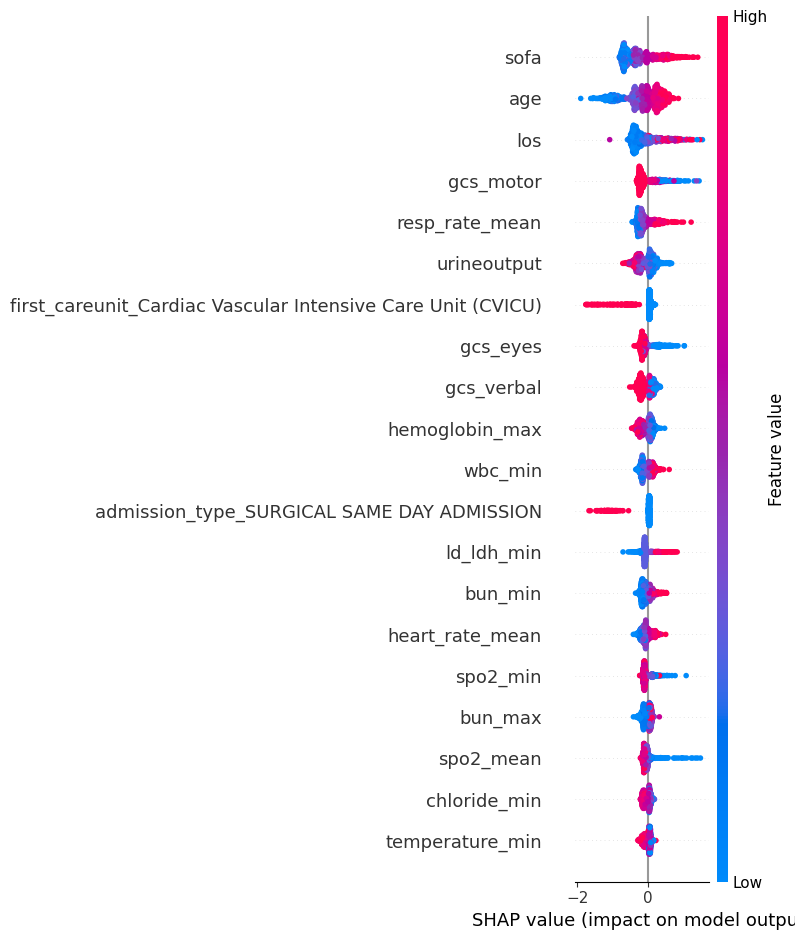

In [17]:
import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(xgb)
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig('shap_summary_mimic.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# remove sofa and related composite scores
cols_to_remove = ['sofa', 'respiration', 'coagulation', 'liver', 'cardiovascular', 'cns', 'renal']
cols_to_remove = [c for c in cols_to_remove if c in X_train.columns]
print(f'Removing: {cols_to_remove}')

X_train_no_sofa = X_train.drop(columns=cols_to_remove)
X_test_no_sofa = X_test.drop(columns=cols_to_remove)

xgb_no_sofa = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='auc'
)

xgb_no_sofa.fit(X_train_no_sofa, y_train,
                eval_set=[(X_test_no_sofa, y_test)],
                verbose=100)

y_prob_no_sofa = xgb_no_sofa.predict_proba(X_test_no_sofa)[:, 1]
y_pred_no_sofa = xgb_no_sofa.predict(X_test_no_sofa)

print(classification_report(y_test, y_pred_no_sofa, target_names=['Survived', 'Died']))
print(confusion_matrix(y_test, y_pred_no_sofa))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_no_sofa):.4f}')

Removing: ['sofa', 'respiration', 'coagulation', 'liver', 'cardiovascular', 'cns', 'renal']
[0]	validation_0-auc:0.84190
[100]	validation_0-auc:0.91038
[200]	validation_0-auc:0.91559
[300]	validation_0-auc:0.91699
[400]	validation_0-auc:0.91766
[499]	validation_0-auc:0.91784
              precision    recall  f1-score   support

    Survived       0.96      0.88      0.92     16622
        Died       0.46      0.77      0.57      2270

    accuracy                           0.86     18892
   macro avg       0.71      0.82      0.75     18892
weighted avg       0.90      0.86      0.88     18892

[[14558  2064]
 [  533  1737]]
AUC-ROC: 0.9178


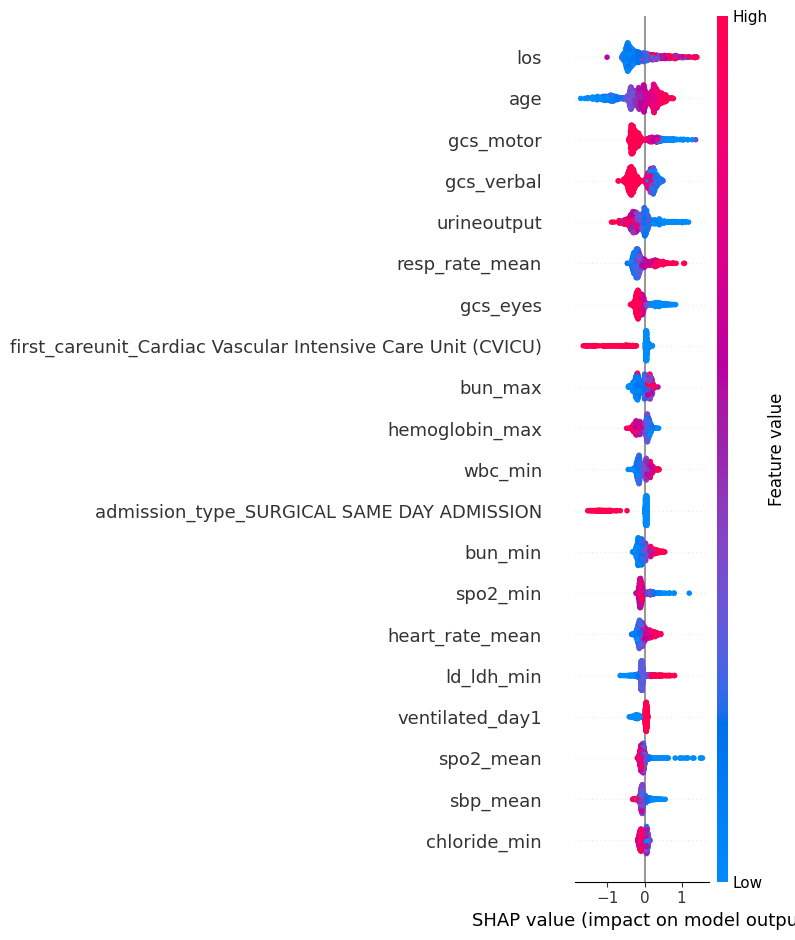

In [19]:
explainer = shap.TreeExplainer(xgb_no_sofa)
X_test_sample = X_test_no_sofa.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig('shap_summary_mimic_no_sofa.png', dpi=150, bbox_inches='tight')
plt.show()